In [13]:
#import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [17]:
# Load the dataset
data = load_breast_cancer()
x = data.data
y = data.target
print("Dataset Shape: ", x.shape)
print("Number of Features: ", x.shape[1])
print("Classes: ", data.target_names)

Dataset Shape:  (569, 30)
Number of Features:  30
Classes:  ['malignant' 'benign']


In [20]:
# Split the dataset
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y  # Ensures that both your training and testing sets keep the exact same percentage of each class or category as your original dataset.
)

print("\nTraining samples: ", x_train.shape[0])
print("\n Testing samples: ", x_test.shape[0])


Training samples:  455

 Testing samples:  114


In [21]:
# Create pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

In [24]:
# Hyperparameter tuning
param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 13, 15],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

In [25]:
# Distance traveled along the grid of perpendicular axes
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5, # S-Fold Cross Validation
    scoring="accuracy"
)

In [26]:
# Train the model
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__metric': ['euclidean', 'manhattan'],
                         'knn__n_neighbors': [3, 5, 7, 9, 11, 13, 15],
                         'knn__weights': ['uniform', 'distance']},
             scoring='accuracy')

In [28]:
# Display the best parameters
print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:") # AVERAGE PERFORMANCE OF THE ML MODEL
print(grid_search.best_score_)


Best Parameters:
{'knn__metric': 'euclidean', 'knn__n_neighbors': 7, 'knn__weights': 'uniform'}

Best Cross Validation Score:
0.9714285714285715


In [29]:
# Make Prediction (Testing)
best_model = grid_search.best_estimator_

y_pred = best_model.predict(x_test)

In [30]:
# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("================ MODEL PERFORMANCE ================")

print("\n1. Accuracy: ", accuracy)
print("2. Precision: ", precision)
print("3. Recall: ", recall)
print("4. F1 Score: ", f1)

================ MODEL PERFORMANCE ================

1. Accuracy:  0.9736842105263158
2. Precision:  0.96
3. Recall:  1.0
4. F1 Score:  0.9795918367346939


In [33]:
# Classification Report
print("\n=============== CLASSIFICATION REPORT ===============")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=data.target_names
    )
)


=============== CLASSIFICATION REPORT ===============
              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        42
      benign       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [34]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[39  3]
 [ 0 72]]


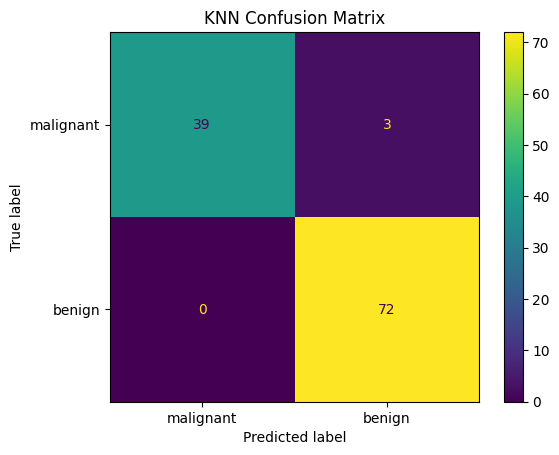

In [35]:
# Display Confusion Matrix
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)
display.plot()
plt.title("KNN Confusion Matrix")
plt.show()

In [40]:
# Predict a New Patient
new_patient = x_test[0].reshape(1, -1)

prediction = best_model.predict(new_patient)

print("\n========== NEW PATIENT PREDICTION ==========")

print("Predicted Class: ", data.target_names[prediction[0]])

if prediction[0] == 0:
  print("Prediction: Malignant")
else:
  print("Prediction: Benign")


========== NEW PATIENT PREDICTION ==========
Predicted Class:  malignant
Prediction: Malignant
